In [ ]:
import os
import time
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.metrics import classification_report

In [ ]:
from torchvision import datasets

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("/kaggle/input/fakeface-train-data-v2", transform=transform)
val_dataset   = datasets.ImageFolder("/kaggle/input/fakeface-valid-data-v2", transform=transform)
test_dataset = datasets.ImageFolder("/kaggle/input/fakeface-test-data-v2", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader   = DataLoader(test_dataset, batch_size=64, shuffle=False,num_workers=2)

In [ ]:
from torchvision import models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MobileNetV2 và sửa classifier
model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import time
import os
import csv
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report

# === Tạo thư mục lưu log & checkpoint trong môi trường Kaggle ===
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
log_file = "/kaggle/working/training_log.csv"

# Ghi header log nếu chưa tồn tại
if not os.path.exists(log_file):
    with open(log_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Epoch", "Train Loss", "Train Acc", "Val Loss", "Val Acc", "Time (s)"])

# === Training Loop (10 epochs) ===
start_time = time.time()
for epoch in range(1, 6):
    epoch_start = time.time()

    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # === Validation ===
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    epoch_time = time.time() - epoch_start

    print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.2f}s")

    # === Ghi log vào file CSV ===
    with open(log_file, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, avg_loss, train_acc, avg_val_loss, val_acc, round(epoch_time, 2)])

    # === Lưu checkpoint ===
    ckpt_path = f"/kaggle/working/checkpoints/mobilenetv2_epoch_{epoch}.pth"
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, ckpt_path)
    print(f"Checkpoint saved: {ckpt_path}")

Epoch 01 | Train Loss: 0.1711 | Train Acc: 0.9275 | Val Loss: 0.1000 | Val Acc: 0.9622 | Time: 548.50s
Checkpoint saved: /kaggle/working/checkpoints/mobilenetv2_epoch_1.pth
Epoch 02 | Train Loss: 0.0382 | Train Acc: 0.9861 | Val Loss: 0.0895 | Val Acc: 0.9689 | Time: 547.15s
Checkpoint saved: /kaggle/working/checkpoints/mobilenetv2_epoch_2.pth
Epoch 03 | Train Loss: 0.0190 | Train Acc: 0.9932 | Val Loss: 0.1160 | Val Acc: 0.9628 | Time: 548.12s
Checkpoint saved: /kaggle/working/checkpoints/mobilenetv2_epoch_3.pth
Epoch 04 | Train Loss: 0.0143 | Train Acc: 0.9948 | Val Loss: 0.1352 | Val Acc: 0.9615 | Time: 547.34s
Checkpoint saved: /kaggle/working/checkpoints/mobilenetv2_epoch_4.pth
Epoch 05 | Train Loss: 0.0123 | Train Acc: 0.9957 | Val Loss: 0.0894 | Val Acc: 0.9721 | Time: 554.57s
Checkpoint saved: /kaggle/working/checkpoints/mobilenetv2_epoch_5.pth


In [ ]:
from torchvision import models
import torch.nn as nn
import torch # Import torch if not already globally available
import os # Import os if not already globally available

# Load the model structure
loaded_model = models.mobilenet_v2()

# Modify the classifier to match the trained model
loaded_model.classifier[1] = nn.Linear(loaded_model.classifier[1].in_features, 2)

# Load the saved state dictionary
device_to_load = torch.device('cpu')

final_model_path = "/content/mobilenetv2_trainv2_ver2.pth"
loaded_model.load_state_dict(torch.load(final_model_path, map_location=device_to_load))


# Calculate parameters for the loaded model
total_params_loaded = sum(p.numel() for p in loaded_model.parameters())
trainable_params_loaded = sum(p.numel() for p in loaded_model.parameters() if p.requires_grad)

print(f" Total parameters (loaded model): {total_params_loaded:,}")
print(f" Trainable parameters (loaded model): {trainable_params_loaded:,}")

 Total parameters (loaded model): 2,226,434
 Trainable parameters (loaded model): 2,226,434


In [ ]:
# === Đánh giá trên Test Set ===
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\n📊 Classification Report on Test Set:")
print(classification_report(y_true, y_pred, target_names=["Fake", "Real"]))


📊 Classification Report on Test Set:
              precision    recall  f1-score   support

        Fake       0.97      0.98      0.97     20000
        Real       0.98      0.96      0.97     20000

    accuracy                           0.97     40000
   macro avg       0.97      0.97      0.97     40000
weighted avg       0.97      0.97      0.97     40000



In [ ]:
print(f"\n Total training time: {time.time() - start_time:.2f} seconds")


 Total training time: 2989.51 seconds


In [ ]:
# === Lưu model đã huấn luyện (final) ===
final_model_path = "/kaggle/working/mobilenetv2.pth"
torch.save(model.state_dict(), final_model_path)
print(f"\nFinal model saved to: {final_model_path}")


Final model saved to: /kaggle/working/mobilenetv2.pth


In [ ]:
# Tổng số tham số
total_params = sum(p.numel() for p in model.parameters())
# Số tham số cần học (có requires_grad=True)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f" Total parameters: {total_params:,}")
print(f" Trainable parameters: {trainable_params:,}")


 Total parameters: 2,226,434
 Trainable parameters: 2,226,434


In [ ]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

def get_auc(model, dataloader):
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)  # shape: [B, 2]
            probs = F.softmax(outputs, dim=1)[:, 1]  # xác suất class "1" (real)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    return auc


In [ ]:
mobilenetv2_auc = get_auc(model, test_loader)

print(f" MobileNetV2 AUC: {mobilenetv2_auc:.4f}")

 MobileNetV2 AUC: 0.9965


In [ ]:
print(test_dataset.class_to_idx)

{'fake': 0, 'real': 1}


In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model, dataloader, model_name="Model"):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)  # shape: [B, 2]
            probs = F.softmax(outputs, dim=1)[:, 1]  # xác suất class 1 (real)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange',
             lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


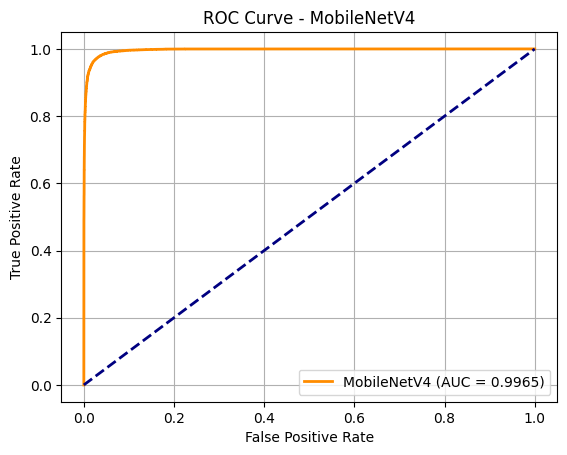

In [ ]:
plot_roc_curve(model, test_loader, model_name="MobileNetV2")


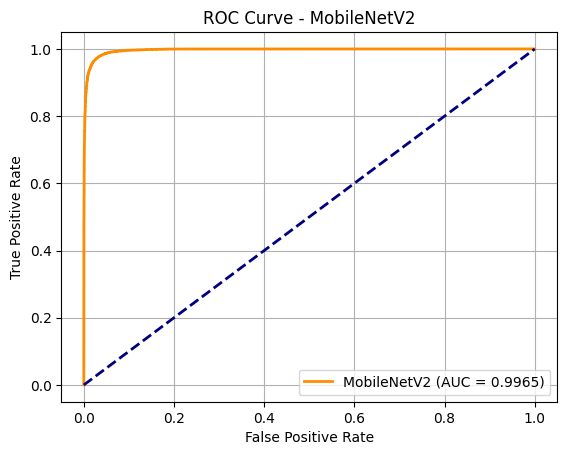

In [ ]:
plot_roc_curve(model, test_loader, model_name="MobileNetV2")
